Import data

In [1]:
import pandas as pd
import pulp 
import matplotlib.pyplot as plt

lanes = pd.read_csv('lanes.csv')
nodes = pd.read_csv('nodes.csv')

print(lanes.head())
print(nodes.head())

  origin destination  cost
0    CVG         LEJ   1.5
1    CVG         HYD   1.6
2    CVG         SBD   0.5
3    AFW         SBD   0.5
4    CVG         C01   1.6
  node_id                          name country   type  capacity  demand
0     CVG  Cincinnati/Northern Kentucky     NaN    hub   95650.0     NaN
1     AFW           Alliance Fort Worth     NaN    hub   44350.0     NaN
2     LEJ                       Leipzig     NaN  focus   85000.0     NaN
3     HYD                     Hyderabad     NaN  focus   19000.0     NaN
4     SBD                San Bernardino     NaN  focus   36000.0     NaN


Split data

In [2]:
hubs = nodes.loc[nodes['type'] == 'hub', 'node_id'].tolist()
focus = nodes.loc[nodes['type'] == 'focus', 'node_id'].tolist()
centers = nodes.loc[nodes['type'] == 'center', 'node_id'].tolist()

capacity =  nodes.set_index('node_id')['capacity'].dropna().to_dict()
demand = nodes.set_index('node_id')['demand'].dropna().to_dict()
cost = {(r.origin, r.destination): r.cost for r in lanes.itertuples()}

Validate data

In [3]:
unknown = (set(lanes['origin']) | set(lanes['destination'])) - set(nodes['node_id'])
assert not unknown, f'unknown nodes: {unknown}'

assert (len(hubs), len(focus), len(centers)) == (2, 3, 65)
assert lanes.duplicated(['origin', 'destination']).sum() == 0

inbound = set(lanes['destination'])
orphans = [c for c in centers if c not in inbound]
assert not orphans, f'centers with no inbound lane: {orphans}'

print(f'total demand: {sum(demand.values()):,.0f}')
print(f'hub capacity: {sum(capacity[h] for h in hubs):,.0f}')
print('validation passed')

total demand: 133,747
hub capacity: 140,000
validation passed


Split by echelon

In [4]:
hub_focus = [(i, j) for (i, j) in cost if i in hubs and j in focus]
hub_center = [(i, k) for (i, k) in cost if i in hubs and k in centers]
focus_center = [(j, k) for (j, k) in cost if j in focus and k in centers]

print(f'x (hub -> focus)   : {len(hub_focus)}')
print(f'y (hub -> center)  : {len(hub_center)}')
print(f'z (focus -> center): {len(focus_center)}')
print(f'total paths        : {len(hub_focus) + len(hub_center) + len(focus_center)}')

x (hub -> focus)   : 4
y (hub -> center)  : 106
z (focus -> center): 82
total paths        : 192


Initialize model

In [5]:
model = pulp.LpProblem('amazon_air', pulp.LpMinimize)

x = pulp.LpVariable.dicts('x', hub_focus, lowBound=0, cat='Continuous')
y = pulp.LpVariable.dicts('y', hub_center, lowBound=0, cat='Continuous')
z = pulp.LpVariable.dicts('z', focus_center, lowBound=0, cat='Continuous')

print(f'x: {len(x)}\ny: {len(y)}\nz: {len(z)}\ntotal: {len(x) + len(y) + len(z)}')
if len(x) == len(hub_focus) and len(y) == len(hub_center) and len(z) == len(focus_center):
    print('Variables successfully assigned.')
else:
    print('Variable assignment unsuccessful')

x: 4
y: 106
z: 82
total: 192
Variables successfully assigned.


Add objective function to the model

In [6]:
model += pulp.lpSum([cost[i, j] * x[i, j] for (i, j) in hub_focus] +
                    [cost[i, k] * y[i, k] for (i, k) in hub_center] +
                    [cost[j, k] * z[j, k] for (j, k) in focus_center]), 'total_cost'


Add model constraints

In [7]:
# hub output
for i in hubs:
    model += (pulp.lpSum(x[i, j] for j in focus if (i, j) in x) +
              pulp.lpSum(y[i, k] for k in centers if (i, k) in y)
              <= capacity[i]), f'hub_capacity_{i}'

# throughput (focus cities)
for j in focus:
    model += (pulp.lpSum(x[i, j] for i in hubs if (i, j) in x)
              <= capacity[j]), f'focus_capacity_{j}'

# flow conservation (focus cities)
for j in focus:
    model += (pulp.lpSum(z[j, k] for k in centers if (j, k) in z) ==
              pulp.lpSum(x[i, j] for i in hubs if (i, j) in x)), f'focus_balance_{j}'

# center demand
for k in centers:
    model += (pulp.lpSum(y[i, k] for i in hubs if (i, k) in y) +
              pulp.lpSum(z[j, k] for j in focus if (j, k) in z)
              == demand[k]), f'demand_{k}'

print(f'constraints: {len(model.constraints)}')

constraints: 73


Solve model

In [8]:
status = model.solve(pulp.PULP_CBC_CMD(msg=True))

print(f'status: {pulp.LpStatus[model.status]}')
print(f'objective: ${pulp.value(model.objective):,.2f}')

status: Optimal
objective: $182,376.25


Extract the model solution

In [9]:
flows = []
for (i, j), var in x.items():
    flows.append({'origin': i, 'destination': j, 'echelon': 'hub_to_focus',
                  'tons': var.value(), 'cost': cost[i, j]})
for (i, k), var in y.items():
    flows.append({'origin': i, 'destination': k, 'echelon': 'hub_to_center',
                  'tons': var.value(), 'cost': cost[i, k]})
for (j, k), var in z.items():
    flows.append({'origin': j, 'destination': k, 'echelon': 'focus_to_center',
                  'tons': var.value(), 'cost': cost[j, k]})

flows = pd.DataFrame(flows)
flows['total_cost'] = flows['tons'] * flows['cost']

active = flows[flows['tons'] > 1e-6].copy()

print(f'lanes in model : {len(flows)}')
print(f'lanes used     : {len(active)}')
print(f'objective check: ${flows["total_cost"].sum():,.2f}')

lanes in model : 192
lanes used     : 68
objective check: $182,376.25


Attach names

In [10]:
names = nodes.set_index('node_id')['name'].to_dict()
active['origin_name'] = active['origin'].map(names)
active['destination_name'] = active['destination'].map(names)

active.sort_values('total_cost', ascending=False).head(15)

,origin,destination,echelon,tons,cost,total_cost,origin_name,destination_name
0,CVG,LEJ,hub_to_focus,24470.0,1.5,36705.0,Cincinnati/Northern Kentucky,Leipzig
1,CVG,HYD,hub_to_focus,19000.0,1.6,30400.0,Cincinnati/Northern Kentucky,Hyderabad
122,LEJ,C07,focus_to_center,14800.0,1.5,22200.0,Leipzig,Mumbai
116,LEJ,C04,focus_to_center,9100.0,1.5,13650.0,Leipzig,Bengaluru
15,CVG,C16,hub_to_center,6700.0,1.6,10720.0,Cincinnati/Northern Kentucky,London
4,CVG,C01,hub_to_center,6500.0,1.6,10400.0,Cincinnati/Northern Kentucky,Paris
121,HYD,C06,focus_to_center,19000.0,0.5,9500.0,Hyderabad,Delhi
13,CVG,C14,hub_to_center,3700.0,1.6,5920.0,Cincinnati/Northern Kentucky,Madrid
12,CVG,C13,hub_to_center,2800.0,1.5,4200.0,Cincinnati/Northern Kentucky,Barcelona
24,CVG,C21,hub_to_center,7200.0,0.5,3600.0,Cincinnati/Northern Kentucky,Los Angeles


Demand

In [11]:
received = active.groupby('destination')['tons'].sum()
demand_check = pd.DataFrame({'required': pd.Series(demand)})
demand_check['received'] = demand_check.index.map(received).fillna(0)
demand_check['gap'] = demand_check['received'] - demand_check['required']

print(f'max demand gap: {demand_check["gap"].abs().max():.6f}')
print(f'centers short : {(demand_check["gap"] < -1e-6).sum()}')

max demand gap: 0.000000
centers short : 0


Focus cities

In [12]:
for j in focus:
    inflow = active[active['destination'] == j]['tons'].sum()
    outflow = active[active['origin'] == j]['tons'].sum()
    print(f'{j}: in {inflow:,.0f} / cap {capacity[j]:,.0f} | out {outflow:,.0f} | balance {inflow - outflow:.6f}')

LEJ: in 24,470 / cap 85,000 | out 24,470 | balance 0.000000
HYD: in 19,000 / cap 19,000 | out 19,000 | balance 0.000000
SBD: in 0 / cap 36,000 | out 0 | balance 0.000000


Hub capacity

In [13]:
hub_out = active[active['origin'].isin(hubs)].groupby('origin')['tons'].sum()
for h in hubs:
    used = hub_out.get(h, 0)
    print(f'{h}: {used:,.0f} / {capacity[h]:,.0f} ({used / capacity[h]:.1%})')

CVG: 95,650 / 95,650 (100.0%)
AFW: 38,097 / 44,350 (85.9%)


Visualize capacity utilization

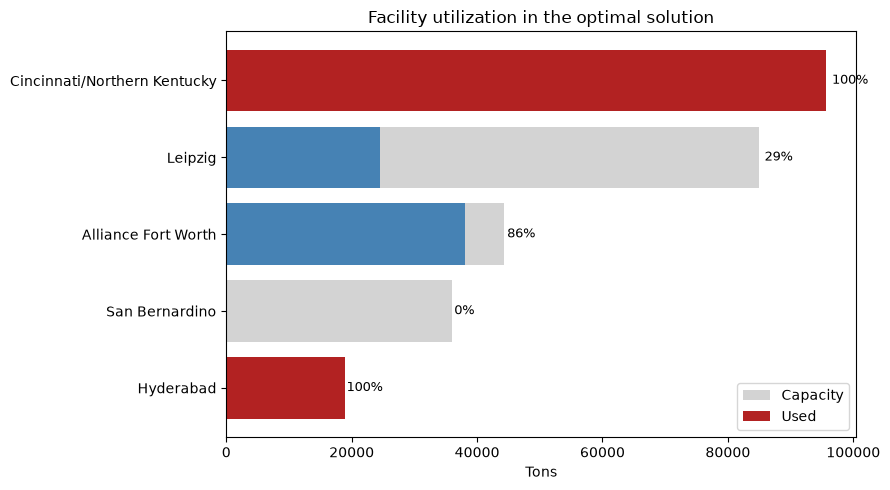

In [14]:
focus_in = active[active['destination'].isin(focus)].groupby('destination')['tons'].sum()

util = pd.DataFrame([
    {'node': n, 'used': hub_out.get(n, 0) if n in hubs else focus_in.get(n, 0),
     'capacity': capacity[n], 'type': 'Hub' if n in hubs else 'Focus city'}
    for n in hubs + focus
])
util['label'] = util['node'].map(names)
util['pct'] = util['used'] / util['capacity']
util = util.sort_values('capacity', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(util['label'], util['capacity'], color='lightgray', label='Capacity')
colors = ['firebrick' if p > 0.999 else 'steelblue' for p in util['pct']]
ax.barh(util['label'], util['used'], color=colors, label='Used')

for y, (used, cap, pct) in enumerate(zip(util['used'], util['capacity'], util['pct'])):
    ax.text(cap * 1.01, y, f'{pct:.0%}', va='center', fontsize=9)

ax.set_xlabel('Tons')
ax.set_title('Facility utilization in the optimal solution')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images/capacity_utilization.png', dpi=150, bbox_inches='tight')
plt.show()

Reconciliation

In [15]:
print(f'total out of hubs: {hub_out.sum():,.0f}')
print(f'total demand     : {sum(demand.values()):,.0f}')
print(f'difference       : {hub_out.sum() - sum(demand.values()):,.0f}')

total out of hubs: 133,747
total demand     : 133,747
difference       : 0


Print objective function

In [16]:
print(f'type        : {pulp.LpSenses[model.sense]}')
print(f'variables   : {len(model.variables())}')
print(f'constraints : {len(model.constraints)}')
print(f'total cost  : ${pulp.value(model.objective):,.2f}')
print()
print(str(model.objective), '...')

type        : Minimize
variables   : 192
constraints : 73
total cost  : $182,376.25

0.5*x_('AFW',_'SBD') + 1.6*x_('CVG',_'HYD') + 1.5*x_('CVG',_'LEJ') + 0.5*x_('CVG',_'SBD') + 0.5*y_('AFW',_'C17') + y_('AFW',_'C18') + y_('AFW',_'C19') + 0.5*y_('AFW',_'C20') + 0.5*y_('AFW',_'C21') + 0.5*y_('AFW',_'C22') + 0.5*y_('AFW',_'C23') + 0.5*y_('AFW',_'C24') + 0.5*y_('AFW',_'C25') + 0.5*y_('AFW',_'C26') + 0.5*y_('AFW',_'C27') + 0.5*y_('AFW',_'C28') + 0.5*y_('AFW',_'C29') + 0.5*y_('AFW',_'C30') + 0.5*y_('AFW',_'C31') + 0.5*y_('AFW',_'C32') + 0.5*y_('AFW',_'C33') + 0.5*y_('AFW',_'C34') + 0.5*y_('AFW',_'C35') + 0.5*y_('AFW',_'C36') + 0.5*y_('AFW',_'C37') + 0.5*y_('AFW',_'C38') + 0.5*y_('AFW',_'C39') + 0.5*y_('AFW',_'C40') + 0.5*y_('AFW',_'C41') + 0.5*y_('AFW',_'C42') + 0.5*y_('AFW',_'C43') + 0.5*y_('AFW',_'C44') + 0.5*y_('AFW',_'C45') + 0.5*y_('AFW',_'C46') + 0.5*y_('AFW',_'C47') + 0.5*y_('AFW',_'C48') + 0.5*y_('AFW',_'C49') + 0.5*y_('AFW',_'C50') + 0.5*y_('AFW',_'C51') + 0.5*y_('AFW',_'C52') + 0.5

In [17]:
by_echelon = active.groupby('echelon').agg(
    lanes=('tons', 'size'),
    tons=('tons', 'sum'),
    cost=('total_cost', 'sum')
)
print(by_echelon)

                 lanes     tons      cost
echelon                                  
focus_to_center      4  43470.0  46205.00
hub_to_center       62  90277.0  69066.25
hub_to_focus         2  43470.0  67105.00
